In [1]:

import numpy as np
from matplotlib import pyplot as plt 
import os

import ipywidgets as widgets
from IPython.display import display, clear_output



def longitud_curva (pulsos  , curve     ) :
    '''La yurva y la lista de pulsos que tomo tiene que estar normalizadsa'''
    d_curve = 0
    for i in range(len (curve) - 1):
       d_curve = d_curve + np.sqrt (  (pulsos[i+1] - pulsos[i] )**2 + (curve[i+1] - curve[i])**2 )
    return d_curve



def calcular_indice_nl (curve):
    ''' Toma una curva de pot/dep, calcula la cantidad de puslsos, normaliza ambas 
    cantidades para que la curva quede en el cuadrado (0,0) (0,1) (1,1) (1,0) y calcula 
    el indice. Con el primer y segundo punto chequea si la curva es creciente o decreciente para
    saber si es pot o dep. RECORDAR: las curvas que genero son monótamente crecientes o decrecientes.'''
    
    if (curve[0] < curve[1]) == True: #esto es una curva de pot
        curve_norm = curve/curve[-1] 
        pulsos_norm = np.linspace(0 , 1, len (curve_norm))
        d = np.sqrt (  (pulsos_norm[-1] - pulsos_norm[0] )**2 + (curve_norm[-1] - curve_norm[0])**2 )
        #d = np.sqrt(2)
        L = longitud_curva (pulsos_norm , curve_norm   )
        return (L - d) /d
    else: # esto es una curve de dep
        curve_norm = curve/curve[0] 
        pulsos_norm = np.linspace(0 , 1, len (curve_norm))
        d = np.sqrt (  (pulsos_norm[-1] - pulsos_norm[0] )**2 + (curve_norm[-1] - curve_norm[0])**2 )
        #d = np.sqrt(2)
        L = longitud_curva (pulsos_norm , curve_norm   )
        return (L - d) /d



def generar_curvas_pot_dep (  pulsos_pot : int, pulsos_dep : int, 
                            a_pot :float, 
                            a_dep :float , 
                            G_min : float , 
                            G_max :float = 0.001, 
                            concavidad_dep : str = 'neg' , 
                            concavidad_pot : str = 'pos' ) :
    
    """
    Función que genera y devuelve las curvas de pot, dep y ratio a partir de la cantidad de puntos, parametro a y
    valores maximos y minimos para la conductancia (esto termina determinando el ratio HRS/LRS)

    """
    #G_max = 0.001 #este queda fijo porque tomo como Rlow 1kohm siempre
    "POT"
    ratio = round(G_max/G_min)
    pp = np.arange(pulsos_pot)
    b = (G_max - G_min)/(1-np.exp(-pulsos_pot/a_pot))
    pot = b*(1 -np.exp(-pp/a_pot)) + G_min
   

    "DEP"
    pd = np.arange(pulsos_dep)
    b = (G_max - G_min)/(1-np.exp(-pulsos_dep/a_dep))
    dep = b*(1 -np.exp(-pd/a_dep)) + G_min
    dep = dep[::-1].copy() #ahora es decreciente. uso copy() porque Torch da problemas (strides invertidos)

    if concavidad_pot == 'pos':
        inl_pot = calcular_indice_nl (pot)
        if concavidad_dep == 'neg':
            dep =( - (dep - (G_max - G_min)) + 2*G_min  )[::-1].copy()
            inl_dep = calcular_indice_nl (dep)
            return pot, dep , round(ratio) , inl_pot, inl_dep
        else: 
            inl_dep = calcular_indice_nl (dep)
            return pot, dep , round(ratio) , inl_pot, inl_dep
    
    else: 
        #concavidad potenciacion negativa
        pot =( - (pot - (G_max - G_min)) + 2*G_min  )[::-1].copy()
        inl_pot = calcular_indice_nl (pot)
        if concavidad_dep == 'neg':
            dep =( - (dep - (G_max - G_min)) + 2*G_min  )[::-1].copy()
            inl_dep = calcular_indice_nl (dep)
            return pot, dep , round(ratio)  , inl_pot, inl_dep
        else: 
            inl_dep = calcular_indice_nl (dep)
            return pot, dep , round(ratio)  , inl_pot, inl_dep
    
    



def construir_plano_corregido(pot, dep):
    """Grilla completa (2N)x(2N): ambos elementos del par diferencial pueden
    tomar cualquier valor de S = pot U dep, en cualquier orden.
    Devuelve tambien S para referencia.
    """
    S = np.concatenate([np.asarray(pot), np.asarray(dep)])
    Wij_full = S[:, None] - S[None, :]
    return Wij_full, S


Text(0.5, 1.0, 'Distribución de los pesos Wij')

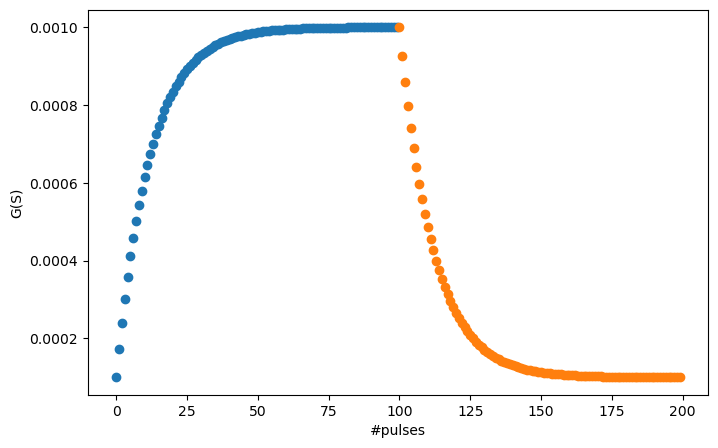

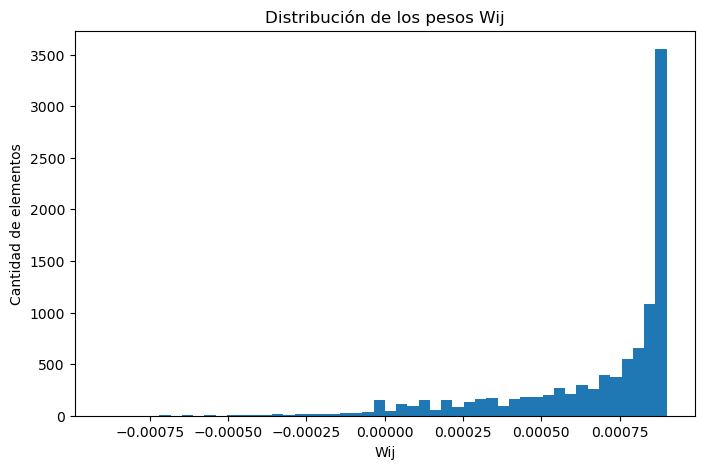

In [2]:

pulsos_pot = 100
pulsos_dep = 100
a_pot =  11.82
a_dep =  11.82
Gmin = 1/10000
Gmax = 1/1000
concavidad_pot = 'pos'
concavidad_dep = 'neg'

pot, dep , rat , aa , cc = generar_curvas_pot_dep (  pulsos_pot , 
                                           pulsos_dep , 
                                           a_pot , 
                                           a_dep , 
                                           Gmin, 
                                           Gmax , 
                                           concavidad_dep,
                                           concavidad_pot  )

plt.figure(figsize=(8, 5))
plt.scatter(np.arange(0,pulsos_pot), pot )
plt.scatter (pulsos_pot + np.arange(0,pulsos_dep ) , dep )
plt.xlabel("#pulses")
plt.ylabel("G(S)")

Wij = np.zeros([pulsos_pot,pulsos_dep])
for i in range(pulsos_pot):
    Wij[i] = pot[i] - dep 


plt.figure(figsize=(8, 5))
plt.hist(Wij.flatten(), bins=50)    
plt.xlabel('Wij')
plt.ylabel('Cantidad de elementos')
plt.title('Distribución de los pesos Wij')


Text(0, 0.5, 'R(Ohm)')

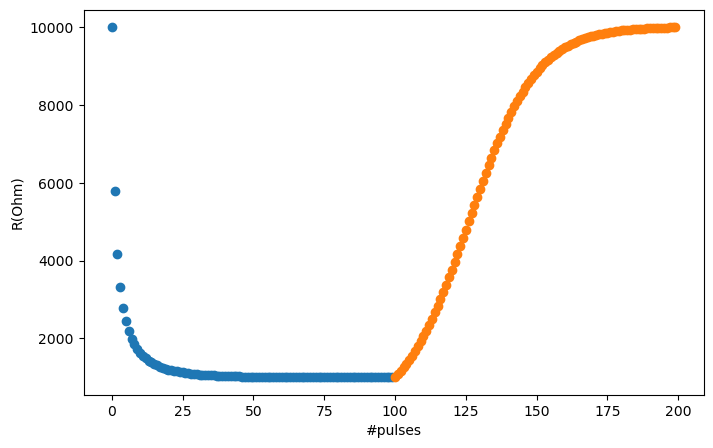

In [3]:
Rpot = []
Rdep = []
for i in range(len(pot)):
    Rpot.append(1/pot[i]) 
    Rdep.append(1/dep[i])




plt.figure(figsize=(8, 5))
plt.scatter(np.arange(0,pulsos_pot), Rpot )
plt.scatter (pulsos_pot + np.arange(0,pulsos_dep ) , Rdep )
plt.xlabel("#pulses")
plt.ylabel("R(Ohm)")    

In [4]:

Wij_full, S = construir_plano_corregido(pot, dep)

# Todas las combinaciones posibles (G_neg, G_pos)
Gn_plano, Gp_plano = np.meshgrid(S, S)


folder_resultados = os.getcwd() + "\\data_beta_grid_search_SP\\beta_grid_search_SP_INL_2e-1_p_100"

file = folder_resultados + \
    "\\G_history_beta_grid_search_SP_INL_2e-1_p_100_job31138190_beta02_b100_serie008.npz"

G_history = np.load(file)


# ============================================================
# CARGAR ACCURACY / LOSS DE ENTRENAMIENTO CORRESPONDIENTES
# ============================================================
# El archivo "resultados_*.npz" agrupa todas las series (repeticiones)
# y folds de una misma corrida. Se identifica a partir del nombre del
# archivo G_history (mismo nombre base, sin el sufijo "_serieXXX").

import re

_nombre_archivo = os.path.basename(file)
_match = re.match(r"G_history_(.*)_serie(\d+)\.npz", _nombre_archivo)
_nombre_base = _match.group(1)
_serie_idx = int(_match.group(2))

file_resultados = folder_resultados + f"\\resultados_{_nombre_base}.npz"

resultados = np.load(file_resultados)

acc_result = resultados["acc_result"]                 # (series, folds, epochs_entrenados)
train_loss_result = resultados["train_loss_result"]   # (series, folds, epochs_entrenados)
saved_epochs_resultados = resultados["saved_epochs"]

fold_idx = 0  # mismo fold usado mas abajo para G_all = G_history["G_layer0_history"][0]

acc_curve = acc_result[_serie_idx, fold_idx, :]
loss_curve = train_loss_result[_serie_idx, fold_idx, :]

# acc_curve/loss_curve pueden no incluir el epoch 0 (estado inicial, sin
# entrenamiento todavia). Se alinean tomando los ultimos N epochs guardados,
# con N = cantidad de puntos de la curva.
epochs_curva = saved_epochs_resultados[-len(acc_curve):].tolist()


In [ ]:
saved_epochs = G_history["saved_epochs"].tolist()


# ============================================================
# MATRICES GUARDADAS
# ============================================================

G_all = G_history["G_layer0_history"][0]


print("Epochs guardados:")
print(saved_epochs)

print()

print("Shape G_all:")
print(G_all.shape)


# ============================================================
# CHEQUEO
# ============================================================

if len(saved_epochs) != len(G_all):

    raise ValueError(
        "La cantidad de saved_epochs no coincide "
        "con la cantidad de matrices guardadas."
    )


# ============================================================
# RANGO Y CANTIDAD DE BINS PARA EL HISTOGRAMA DE PESOS Wij
# ============================================================
# Wij = Gp - Gn, con Gp, Gn en S -> el rango teorico maximo es
# el mismo que el de Wij_full = S[:,None] - S[None,:]
#
# El plano de conductancias (Gn_plano, Gp_plano) es una grilla cuadrada
# de len(S) x len(S) puntos. La diagonal que va desde la esquina
# superior izquierda hasta la esquina inferior derecha de ese plano
# tiene exactamente len(S) puntos (uno por cada nivel de conductancia
# de S). Usamos esa cantidad de puntos como cantidad de bins del
# histograma, para que la resolucion del histograma quede atada a la
# resolucion real del plano de conductancias.

_wij_min = S.min() - S.max()
_wij_max = S.max() - S.min()

_n_bins_wij = len(S)  # puntos sobre la diagonal del plano de conductancias

_wij_bins = np.linspace(_wij_min, _wij_max, _n_bins_wij + 1)

# Rango simetrico fijo para el color de los estados posibles (Wij), asi
# la escala de colores es la misma en todos los epochs y es comparable.
_wij_abs_max = max(abs(_wij_min), abs(_wij_max))

# Wij de cada estado posible del plano: Gp_plano - Gn_plano = Wij_full
# (S[i] - S[j] con Gp_plano[i,j] = S[i], Gn_plano[i,j] = S[j])
_wij_posibles = Wij_full


# ============================================================
# APPLET
# ============================================================

output = widgets.Output()


# ------------------------------------------------------------
# SLIDER
# ------------------------------------------------------------

epoch_slider = widgets.SelectionSlider(

    options=saved_epochs,

    value=saved_epochs[0],

    description="Epoch:",

    continuous_update=True,

    layout=widgets.Layout(
        width="750px"
    )
)


# ============================================================
# FUNCIÓN DE PLOT
# ============================================================

def plot_epoch(epoch_real):

    """
    epoch_real es el número real del epoch,
    por ejemplo:

        10
        20
        50
        60
        80
        100
    """

    # --------------------------------------------------------
    # Buscar qué posición ocupa ese epoch
    # --------------------------------------------------------

    idx = saved_epochs.index(epoch_real)


    # --------------------------------------------------------
    # Cargar la matriz correspondiente
    # --------------------------------------------------------

    G = G_all[idx]


    # --------------------------------------------------------
    # Separar pares diferenciales
    #
    # columnas:
    #
    # G+  G-  G+  G-  G+  G- ...
    # --------------------------------------------------------

    Gp = G[:, 0::2]

    Gn = G[:, 1::2]


    # --------------------------------------------------------
    # Pesos efectivos Wij = Gp - Gn de la red en este epoch
    # --------------------------------------------------------

    Wij_epoch = Gp - Gn


    # --------------------------------------------------------
    # Posición del epoch actual dentro de las curvas de
    # accuracy / loss (pueden no incluir el epoch 0)
    # --------------------------------------------------------

    idx_curva = (
        epochs_curva.index(epoch_real)
        if epoch_real in epochs_curva
        else None
    )


    # --------------------------------------------------------
    # Actualizar gráfico
    # --------------------------------------------------------

    with output:

        clear_output(wait=True)


        # ====================================================
        # LAYOUT: plano de conductancias grande a la izquierda,
        # curvas y el histograma mas chicos apilados a la derecha
        # ====================================================
        # plt.ioff(): la figura se crea con el modo interactivo apagado
        # para que el backend inline de Jupyter NO la registre para su
        # auto-display de fin de celda. La mostramos nosotros mismos,
        # una unica vez, con display(fig) mas abajo.

        plt.ioff()

        fig = plt.figure(figsize=(15, 8))

        gs = fig.add_gridspec(
            3, 2,
            width_ratios=[2.2, 1],
        )

        ax = fig.add_subplot(gs[:, 0])
        ax_acc = fig.add_subplot(gs[0, 1])
        ax_loss = fig.add_subplot(gs[1, 1])
        ax_hist = fig.add_subplot(gs[2, 1])


        # ====================================================
        # ESTADOS POSIBLES, coloreados segun su Wij = Gp - Gn
        # ====================================================

        sc_posibles = ax.scatter(

            Gn_plano.flatten(),

            Gp_plano.flatten(),

            c=_wij_posibles.flatten(),

            cmap="coolwarm",

            vmin=-_wij_abs_max,

            vmax=_wij_abs_max,

            s=8,

            alpha=0.5,

            zorder=1,

        )

        cbar = fig.colorbar(sc_posibles, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Wij = G_pos - G_neg")


        # ====================================================
        # ESTADOS DE LA RED (mismo color para todos los puntos)
        # ====================================================

        ax.scatter(

            Gn.flatten(),

            Gp.flatten(),

            color="black",

            s=12,

            alpha=0.7,

            zorder=3,

        )


        # ====================================================
        # EJES
        # ====================================================

        ax.set_xlabel(
            "G_neg"
        )

        ax.set_ylabel(
            "G_pos"
        )


        # ====================================================
        # TÍTULO
        # ====================================================

        ax.set_title(

            f"Estados de conductancia\n"
            f"Epoch = {epoch_real}   |   "
            f"Cantidad de pesos = {Gn.size}"
        )


        # ====================================================
        # LÍMITES FIJOS
        # ====================================================

        margen = (
            S.max() - S.min()
        ) * 0.03


        ax.set_xlim(
            S.min() - margen,
            S.max() + margen
        )

        ax.set_ylim(
            S.min() - margen,
            S.max() + margen
        )


        # ====================================================
        # MISMA ESCALA X / Y
        # ====================================================

        ax.set_aspect(
            "equal",
            adjustable="box"
        )


        # ====================================================
        # RECTA Wij = 0 (G_pos = G_neg)
        # ====================================================

        _diag_lims = ax.get_xlim()

        ax.plot(
            _diag_lims,
            _diag_lims,
            color="red",
            linewidth=1.6,
            alpha=0.55,
            solid_capstyle="round",
            zorder=4,
        )


        ax.grid(
            alpha=0.2
        )


        # ====================================================
        # ACCURACY VS EPOCH
        # ====================================================

        ax_acc.plot(
            epochs_curva,
            acc_curve,
            "-o",
            markersize=2,
            linewidth=1,
            alpha=0.7,
        )

        if idx_curva is not None:

            ax_acc.plot(
                epochs_curva[idx_curva],
                acc_curve[idx_curva],
                "o",
                color="red",
                markersize=7,
                zorder=5,
            )

        ax_acc.set_xlabel("Epoch", fontsize=8)
        ax_acc.set_ylabel("Accuracy", fontsize=8)
        ax_acc.set_title("Accuracy vs Epoch", fontsize=9)
        ax_acc.tick_params(labelsize=7)
        ax_acc.grid(alpha=0.2)


        # ====================================================
        # TRAIN LOSS VS EPOCH
        # ====================================================

        ax_loss.plot(
            epochs_curva,
            loss_curve,
            "-o",
            markersize=2,
            linewidth=1,
            alpha=0.7,
            color="tab:orange",
        )

        if idx_curva is not None:

            ax_loss.plot(
                epochs_curva[idx_curva],
                loss_curve[idx_curva],
                "o",
                color="red",
                markersize=7,
                zorder=5,
            )

        ax_loss.set_xlabel("Epoch", fontsize=8)
        ax_loss.set_ylabel("Train loss", fontsize=8)
        ax_loss.set_title("Train Loss vs Epoch", fontsize=9)
        ax_loss.tick_params(labelsize=7)
        ax_loss.grid(alpha=0.2)


        # ====================================================
        # HISTOGRAMA DE LOS PESOS Wij DE LA RED EN ESTE EPOCH
        # ====================================================

        ax_hist.hist(
            Wij_epoch.flatten(),
            bins=_wij_bins,
            color="tab:green",
            alpha=0.7,
        )

        ax_hist.set_xlim(_wij_min, _wij_max)

        ax_hist.set_xlabel("Wij", fontsize=8)
        ax_hist.set_ylabel("Cantidad", fontsize=8)
        ax_hist.set_title(f"Distribución de Wij — epoch {epoch_real}", fontsize=9)
        ax_hist.tick_params(labelsize=7)
        ax_hist.grid(alpha=0.2)


        fig.tight_layout()

        # Se muestra la figura UNA sola vez de forma explicita (en vez de
        # plt.show()) y se cierra enseguida, para que no quede registrada
        # como figura "activa" y el backend inline no la vuelva a mostrar
        # sola al terminar de ejecutar la celda (eso era lo que producia
        # el grafico duplicado / triplicado).
        display(fig)
        plt.close(fig)


# ============================================================
# CALLBACK DEL SLIDER
# ============================================================

def actualizar(change):

    if change["name"] == "value":

        plot_epoch(
            change["new"]
        )


epoch_slider.observe(
    actualizar,
    names="value"
)


# ============================================================
# MOSTRAR APPLET
# ============================================================

display(
    epoch_slider,
    output
)


# mostrar primer epoch
plot_epoch(
    saved_epochs[0]
)